# Modul 1: Fondasi Jaringan Saraf, FNN, Aktivasi, dan Loss

**Nama: Adil Aulia Rahma Nurhidayah**  
**NIM: 122450058**  
**Kelas:RA**   
**Tanggal: 16 September 2026**  

**Berkas pengumpulan:** `M01_NIM.ipynb`, `M01_NIM.pdf`, dan `M01_NIM_metrics.csv`.

> Seluruh kode, eksperimen, grafik, dan analisis merupakan pekerjaan individual. Beri atribusi pada kode yang diadaptasi dari sumber lain.

## Petunjuk

1. Ganti seluruh penanda `TODO`.
2. Jangan mengubah protokol eksperimen kecuali diminta.
3. Gunakan validation set untuk memilih model. Test set hanya untuk model final.
4. Sebelum mengumpulkan, jalankan **Restart Kernel and Run All**.
5. Pertahankan semua hasil eksperimen, termasuk hasil yang tidak sesuai hipotesis.

In [41]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\MSI GF\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [42]:
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from sklearn.datasets import make_moons
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

NIM = '122450058'  # TODO: ganti dengan NIM lengkap
assert NIM.isdigit() and len(NIM) >= 4, 'Isi NIM dengan angka sebelum melanjutkan.'
NIM_LAST4 = int(NIM[-4:])
SEED = 1000 + NIM_LAST4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
pd.set_option('display.precision', 4)
environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'sklearn': sklearn.__version__,
    'torch': torch.__version__,
    'device': str(DEVICE),
    'seed': SEED,
}
environment

{'python': '3.11.9',
 'numpy': '2.4.6',
 'pandas': '3.0.6',
 'sklearn': '1.9.1',
 'torch': '2.14.0+cpu',
 'device': 'cpu',
 'seed': 1058}

## A. Pre-lab - 10 poin

Jawab sebelum sesi praktikum.

1. **Parameter vs hyperparameter:** TODO
2. **Mengapa tumpukan layer affine tanpa aktivasi dapat diciutkan:** TODO
3. **Shape bobot layer 2 masukan -> 8 keluaran:** TODO
4. **Mengapa `BCEWithLogitsLoss` menerima logit:** TODO

### Hipotesis awal

Prediksi aktivasi dan hidden size yang akan memberi validation loss terbaik. Jelaskan alasannya sebelum menjalankan eksperimen.

**Jawaban:** TODO

## B. Neuron dan fungsi aktivasi dengan NumPy - 20 poin

In [43]:
def sigmoid_np(z: np.ndarray) -> np.ndarray:
    # implementasikan sigmoid yang stabil untuk nilai positif/negatif besar.
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1 / (1 + np.exp(-z[pos]))
    exp_z = np.exp(z[~pos])
    out[~pos] = exp_z / (1 + exp_z)
    return out

def relu_np(z: np.ndarray) -> np.ndarray:
    return np.maximum(0, z)

def leaky_relu_np(z: np.ndarray, alpha: float = 0.01) -> np.ndarray:
    return np.where(z > 0, z, alpha * z)

def neuron_batch(X: np.ndarray, w: np.ndarray, b: float, activation):
    # validasi shape
    if X.ndim != 2:
        raise ValueError("X harus berupa array 2 dimensi.")
    if w.ndim != 1:
        raise ValueError("w harus berupa array 1 dimensi.")
    if X.shape[1] != w.shape[0]:
        raise ValueError("Jumlah fitur X harus sama dengan panjang w.")

    # hitung z dan a
    z = X @ w + b
    a = activation(z)

    return z, a

# Uji minimum - jangan mengubah data uji.
X_check = np.array([[2.0, -1.0], [0.0, 3.0], [-2.0, 1.0]])
w_check = np.array([0.5, -0.5])
z_check, a_check = neuron_batch(X_check, w_check, 0.25, sigmoid_np)
assert z_check.shape == (3,)
assert a_check.shape == (3,)
assert np.all(np.isfinite(a_check))
assert np.all((a_check > 0) & (a_check < 1))
pd.DataFrame({'z': z_check, 'sigmoid(z)': a_check})

,z,sigmoid(z)
0,1.75,0.8520
1,-1.25,0.2227
2,-1.25,0.2227


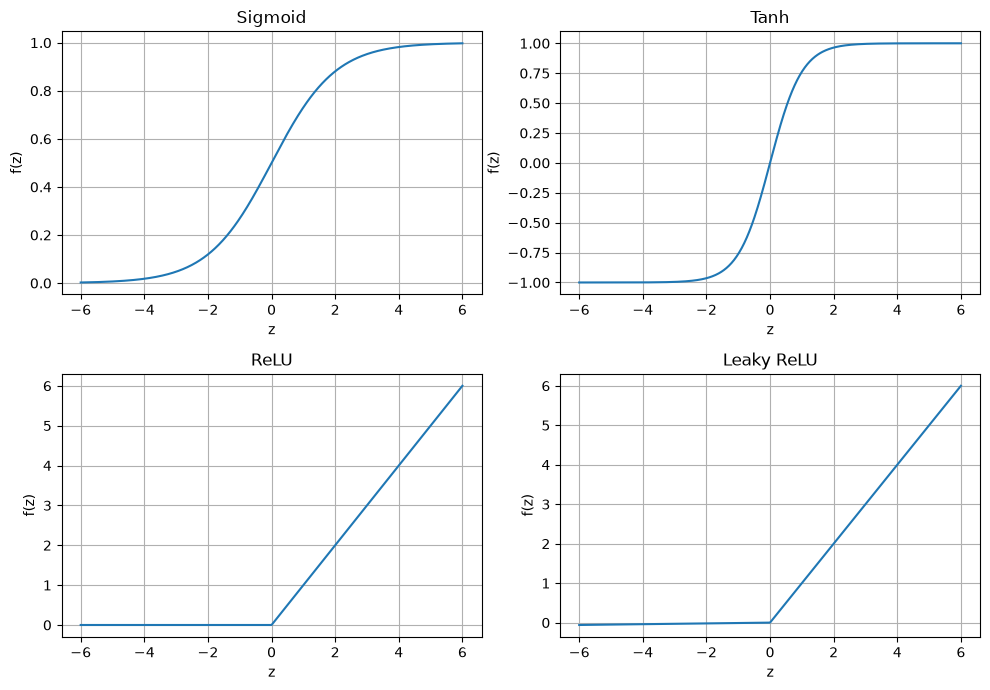

In [44]:
grid = np.linspace(-6, 6, 600)

# Lengkapi kamus dengan empat aktivasi.
activation_values = {
    'Sigmoid': sigmoid_np(grid),
    'Tanh': np.tanh(grid),
    'ReLU': relu_np(grid),
    'Leaky ReLU': leaky_relu_np(grid),
}

# Buat subplot 2x2.
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, (name, values) in zip(axes.ravel(), activation_values.items()):
    ax.plot(grid, values)
    ax.set_title(name)
    ax.set_xlabel('z')
    ax.set_ylabel('f(z)')
    ax.grid(True)

plt.tight_layout()
plt.show()

### Interpretasi aktivasi

- Aktivasi yang berpusat di nol: TODO
- Aktivasi yang tepat nol untuk masukan negatif: TODO
- Aktivasi yang mudah jenuh: TODO
- Mengapa aktivasi linear tidak cukup untuk `make_moons`: TODO

## C. Forward pass manual - bagian dari 20 poin pemetaan

Gunakan arsitektur $2 \rightarrow 2 \rightarrow 1$, ReLU pada hidden layer, dan target $y=1$. Jangan mengubah bobot.

In [45]:
x_manual = np.array([[2.0, -1.0]], dtype=np.float32) 
W1 = np.array([[0.5, -0.5], [1.0, 1.0]], dtype=np.float32) 
b1 = np.array([0.0, 0.0], dtype=np.float32) 
W2 = np.array([[2.0, -1.0]], dtype=np.float32) 
b2 = np.array([0.5], dtype=np.float32) 
y_manual = np.array([[1.0]], dtype=np.float32) 
 
# TODO: hitung z1, h, logit, probabilitas, dan BCE. 
z1_np = x_manual @ W1.T + b1
h_np = np.maximum(0, z1_np)
logit_np = h_np @ W2.T + b2
prob_np = sigmoid_np(logit_np)
bce_np = -np.mean(
    y_manual * np.log(prob_np) +
    (1 - y_manual) * np.log(1 - prob_np)
)
 
# TODO: hitung parameter manual dari ukuran W1, b1, W2, b2. 
parameter_count_manual = W1.size + b1.size + W2.size + b2.size
 
# Hapus baris berikut setelah seluruh nilai diisi. 
# raise NotImplementedError('Lengkapi forward pass manual.')

In [46]:
print("x =", x_manual, x_manual.shape)
print("W1 =", W1, W1.shape)
print("z1 =", z1_np, z1_np.shape)
print("h =", h_np, h_np.shape)
print("logit =", logit_np, logit_np.shape)
print("probabilitas =", prob_np, prob_np.shape)
print("BCE =", bce_np)
print("Jumlah parameter =", parameter_count_manual)

x = [[ 2. -1.]] (1, 2)
W1 = [[ 0.5 -0.5]
 [ 1.   1. ]] (2, 2)
z1 = [[1.5 1. ]] (1, 2)
h = [[1.5 1. ]] (1, 2)
logit = [[2.5]] (1, 1)
probabilitas = [[0.92414182]] (1, 1)
BCE = 0.07888972967562143
Jumlah parameter = 9


### Tabel shape dan nilai

| Tensor | Shape | Nilai |
|---|---:|---:|
| $x$ | $(1,2)$ | $[[2.0,-1.0]]$ |
| $W^{(1)}$ | $(2,2)$ | $[[0.5,-0.5],[1.0,1.0]]$ |
| $z^{(1)}$ | $(1,2)$ | $[[1.5,1.0]]$ |
| $h$ | $(1,2)$ | $[[1.5,1.0]]$ |
| logit | $(1,1)$ | $[[2.5]]$ |
| probabilitas | $(1,1)$ | $[[0.9241]]$ |
| BCE | skalar | $0.07889$ |

**Jumlah parameter dan perhitungannya:** $(2\times2)+2+(1\times2)+1=9$

## D. Pencocokan NumPy dan PyTorch - 20 poin

Salin bobot ke `nn.Sequential`. Jangan menambahkan sigmoid ke model karena loss menerima logit.

In [47]:
manual_model = nn.Sequential(
    nn.Linear(2, 2),
    nn.ReLU(),
    nn.Linear(2, 1),
)

# TODO: salin W1, b1, W2, b2 menggunakan torch.no_grad().
with torch.no_grad():
    manual_model[0].weight.copy_(torch.tensor(W1))
    manual_model[0].bias.copy_(torch.tensor(b1))
    manual_model[2].weight.copy_(torch.tensor(W2))
    manual_model[2].bias.copy_(torch.tensor(b2))

# TODO: hitung torch_logit, torch_probability, dan torch_loss.
torch_logit = manual_model(torch.tensor(x_manual))
torch_probability = torch.sigmoid(torch_logit)
torch_loss = torch.nn.functional.binary_cross_entropy_with_logits(
    torch_logit, torch.tensor(y_manual)
)

# TODO: aktifkan dan lengkapi pemeriksaan berikut.
assert np.max(np.abs(torch_logit.detach().numpy() - logit_np)) < 1e-6
assert abs(torch_loss.item() - float(bce_np)) < 1e-6
assert sum(p.numel() for p in manual_model.parameters()) == parameter_count_manual

### Checkpoint menit ke-85

Tunjukkan kepada asisten:

- plot empat fungsi aktivasi;
- tabel shape dan parameter; dan
- selisih forward NumPy-PyTorch kurang dari $10^{-6}$.

**Status/verifikasi asisten:** TODO

## E. Dataset dan protokol eksperimen

Kode split dan standardisasi diberikan agar fokus tetap pada FNN. Jangan menggunakan test set sampai model final dipilih.

,split,n,positive_rate
0,train,360,0.5
1,validation,120,0.5
2,test,120,0.5


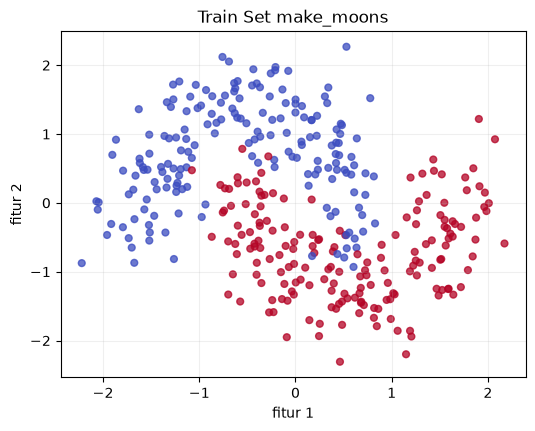

In [48]:
X, y = make_moons(n_samples=600, noise=0.22, random_state=SEED)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)
y_val_f = y_val.astype(np.float32).reshape(-1, 1)
y_test_f = y_test.astype(np.float32).reshape(-1, 1)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'n': [len(y_train), len(y_val), len(y_test)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap='coolwarm', s=24, alpha=0.75)
ax.set(title='Train Set make_moons', xlabel='fitur 1', ylabel='fitur 2')
ax.grid(alpha=0.2)
plt.show()

### Pemeriksaan anti-leakage

Jelaskan mengapa scaler hanya di-fit pada train set dan bukan seluruh data.

**Jawaban:** Scaler hanya di-fit pada train set agar tidak terjadi *data leakage*. Parameter standardisasi, yaitu mean dan standar deviasi, harus dihitung hanya dari data training. Jika scaler di-fit menggunakan seluruh data, informasi dari validation dan test set ikut masuk ke proses pelatihan sehingga evaluasi model menjadi tidak objektif. Setelah scaler di-fit pada train set, scaler yang sama digunakan untuk mentransformasi data validation dan test.


## F. Model dan utilitas training

Lengkapi pemilihan aktivasi dan model. Training loop diberikan; mekanismenya dibahas pada Modul 2.

In [49]:
def activation_layer(name: str) -> nn.Module:
    # TODO: kembalikan objek nn.ReLU(), nn.Tanh(), atau nn.Sigmoid().
    if name == 'relu':
        return nn.ReLU()
    elif name == 'tanh':
        return nn.Tanh()
    elif name == 'sigmoid':
        return nn.Sigmoid()
    else:
        raise ValueError(f"Unknown activation: {name}")

def build_model(hidden_dim: int, activation: str, seed: int = SEED):
    seed_everything(seed)
    # TODO: bangun arsitektur 2 -> hidden_dim -> 1 tanpa sigmoid output.
    return nn.Sequential(
        nn.Linear(2, hidden_dim),
        activation_layer(activation),
        nn.Linear(hidden_dim, 1)
    )

def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())

# TODO: buat model 2 -> 8 -> 1 dan buktikan jumlah parameternya 4h+1 = 33.
model_check = build_model(8, 'relu')
assert count_parameters(model_check) == 33

In [50]:
def as_tensor(array):
    return torch.as_tensor(array, dtype=torch.float32)

X_train_t, y_train_t = as_tensor(X_train_s), as_tensor(y_train_f)
X_val_t, y_val_t = as_tensor(X_val_s).to(DEVICE), as_tensor(y_val_f).to(DEVICE)
X_test_t, y_test_t = as_tensor(X_test_s).to(DEVICE), as_tensor(y_test_f).to(DEVICE)

def evaluate(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y_tensor).item()
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).to(torch.int64)
        accuracy = (predictions == y_tensor.to(torch.int64)).float().mean().item()
    return {
        'loss': loss,
        'accuracy': accuracy,
        'probabilities': probabilities.cpu().numpy().ravel(),
        'predictions': predictions.cpu().numpy().ravel(),
    }

def train_model(model, epochs=200, learning_rate=0.05, batch_size=32, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size, shuffle=True, generator=generator,
    )
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    history = []
    start = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(X_batch)
        val_metrics = evaluate(model, X_val_t, y_val_t)
        history.append({
            'epoch': epoch,
            'train_loss': loss_sum / len(X_train_t),
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
    return pd.DataFrame(history), time.perf_counter() - start

## G. Baseline dan latihan kelas

Baseline: ReLU, hidden size 8, SGD, learning rate 0.05, batch size 32, dan 200 epoch.

Latihan individual: digit terakhir NIM 0-4 memakai tanh; 5-9 memakai sigmoid. Prediksi hasil sebelum menjalankan.

**Prediksi:** Model dengan aktivasi Sigmoid diperkirakan dapat mempelajari pola pada dataset `make_moons` dan menghasilkan akurasi validasi yang cukup baik, tetapi hasilnya dapat berbeda dari baseline ReLU karena fungsi aktivasi yang digunakan berbeda.


In [51]:
# TODO: latih baseline, tampilkan kurva train/validation loss, dan catat metrik.
baseline_model = build_model(8, 'relu')
baseline_history, baseline_time = train_model(
    baseline_model,
    epochs=200,
    learning_rate=0.05,
    batch_size=32
)

# TODO: latih satu variasi individual dengan komponen lain tetap.
individual_model = build_model(8, 'sigmoid')
individual_history, individual_time = train_model(
    individual_model,
    epochs=200,
    learning_rate=0.05,
    batch_size=32
)

## H. Tugas individual: enam eksperimen - 20 poin

Jalankan kombinasi aktivasi `{relu, tanh, sigmoid}` dan hidden size `{4, 16}`. Gunakan validation loss untuk memilih model.

In [52]:
ACTIVATIONS = ['relu', 'tanh', 'sigmoid'] 
HIDDEN_SIZES = [4, 16] 
EPOCHS = 200 
LEARNING_RATE = 0.05 
BATCH_SIZE = 32 
 
experiment_rows = [] 
trained_models = {} 
histories = {} 
 
# TODO: untuk setiap kombinasi: 
# 1. buat model baru dengan seed yang sama; 
# 2. latih dengan anggaran tetap; 
# 3. evaluasi train dan validation; 
# 4. simpan model/history; 
# 5. tambahkan satu dictionary metrik ke experiment_rows. 

for activation in ACTIVATIONS:
    for hidden_dim in HIDDEN_SIZES:
        model = build_model(hidden_dim, activation, seed=SEED)

        history, train_time = train_model(
            model,
            epochs=EPOCHS,
            learning_rate=LEARNING_RATE,
            batch_size=BATCH_SIZE,
            seed=SEED
        )

        train_metrics = evaluate(model, X_train_t, y_train_t)
        val_metrics = evaluate(model, X_val_t, y_val_t)

        trained_models[(activation, hidden_dim)] = model
        histories[(activation, hidden_dim)] = history

        experiment_rows.append({
            'activation': activation,
            'hidden_dim': hidden_dim,
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
            'train_time': train_time,
            'parameters': count_parameters(model)
        })

results = pd.DataFrame(experiment_rows).sort_values('val_loss').reset_index(drop=True)
assert len(results) == 6
display(results)
results.to_csv(f'M01_{NIM_LAST4:04d}_metrics.csv', index=False)

,activation,hidden_dim,train_loss,train_accuracy,val_loss,val_accuracy,train_time,parameters
0,relu,16,0.1769,0.9306,0.1671,0.9417,2.0822,65
1,tanh,16,0.2133,0.9167,0.1921,0.9250,1.8568,65
2,sigmoid,16,0.3014,0.8778,0.2809,0.8750,1.8838,65
3,sigmoid,4,0.3072,0.8806,0.2921,0.8750,1.7883,17
4,tanh,4,0.3019,0.8778,0.2942,0.8667,1.9278,17
5,relu,4,0.2928,0.8806,0.2971,0.8750,1.9199,17


In [53]:
import os
print(os.path.abspath(f'M01_{NIM_LAST4:04d}_metrics.csv'))

c:\Users\MSI GF\praktikum-dl\kelas-a\Modul-Praktikum-Deep-Learning\notebooks\modul-01\M01_0058_metrics.csv


## I. Evaluasi model final - 15 poin

Pilih satu model dengan validation loss terendah. Baru setelah itu evaluasi test set satu kali.

### Pemilihan Model Final

Berdasarkan hasil enam eksperimen, model dengan fungsi aktivasi **ReLU** dan **hidden size 16** memiliki *validation loss* terendah, yaitu sebesar **0,1671**. Oleh karena itu, model tersebut dipilih sebagai **model final** dan selanjutnya digunakan untuk evaluasi pada *test set*.


Model final: relu, hidden size 16
Test loss: 0.1694
Test accuracy: 0.9417


,Predicted 0,Predicted 1
Actual 0,54,6
Actual 1,1,59


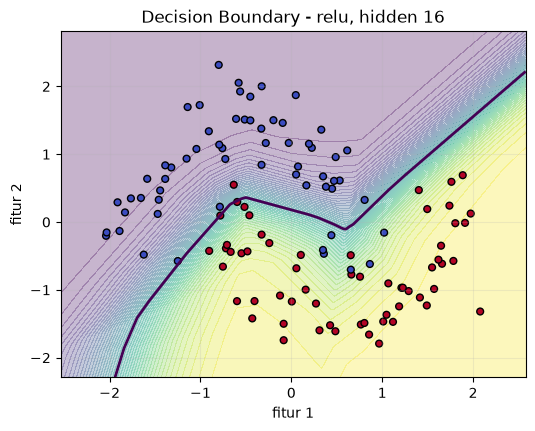

In [54]:
def plot_decision_boundary(model, X_values, y_values, title):
    # TODO: buat mesh, prediksi probabilitas, contourf, batas 0.5, dan scatter data.
    x_min, x_max = X_values[:, 0].min() - 0.5, X_values[:, 0].max() + 0.5
    y_min, y_max = X_values[:, 1].min() - 0.5, X_values[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.as_tensor(grid, dtype=torch.float32).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(model(grid_tensor)).cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(6, 4.5))
    plt.contourf(xx, yy, probabilities, levels=50, alpha=0.3)
    plt.contour(xx, yy, probabilities, levels=[0.5], linewidths=2)
    plt.scatter(X_values[:, 0], X_values[:, 1], c=y_values, cmap='coolwarm', s=24, edgecolor='k')
    plt.title(title)
    plt.xlabel('fitur 1')
    plt.ylabel('fitur 2')
    plt.grid(alpha=0.2)
    plt.show()


# TODO: ambil run_id terbaik dari results.
best_row = results.iloc[0]
best_activation = best_row['activation']
best_hidden_dim = int(best_row['hidden_dim'])

final_model = trained_models[(best_activation, best_hidden_dim)]

# TODO: hitung test loss dan test accuracy satu kali.
test_metrics = evaluate(final_model, X_test_t, y_test_t)

print(f"Model final: {best_activation}, hidden size {best_hidden_dim}")
print(f"Test loss: {test_metrics['loss']:.4f}")
print(f"Test accuracy: {test_metrics['accuracy']:.4f}")

# TODO: tampilkan confusion matrix dan decision boundary model final.
cm = confusion_matrix(
    y_test_f.ravel(),
    test_metrics['predictions']
)

display(pd.DataFrame(
    cm,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
))

plot_decision_boundary(
    final_model,
    X_test_s,
    y_test_f.ravel(),
    f'Decision Boundary - {best_activation}, hidden {best_hidden_dim}'
)

## J. Analisis dan Refleksi

**1. Apakah hidden size lebih besar selalu memperbaiki validation loss?**

Tidak selalu, tetapi pada ketiga aktivasi yang diuji, hidden size 16 menghasilkan *validation loss* yang lebih rendah dibandingkan hidden size 4. Pada ReLU, *validation loss* turun dari **0,2971** menjadi **0,1671**, pada Tanh dari **0,2942** menjadi **0,1921**, dan pada Sigmoid dari **0,2921** menjadi **0,2809**.

**2. Aktivasi mana yang paling stabil pada dua hidden size?**

Berdasarkan perubahan *validation loss* antara hidden size 4 dan 16, **Sigmoid** menunjukkan perubahan paling kecil, yaitu dari **0,2921** menjadi **0,2809**. Selisihnya hanya sekitar **0,0112**, sedangkan ReLU dan Tanh mengalami perubahan yang lebih besar.

**3. Adakah konfigurasi dengan accuracy serupa tetapi BCE berbeda? Mengapa?**

Ada. Contohnya ReLU 4 dan Sigmoid 16 sama-sama memiliki *validation accuracy* **87,50%**, tetapi *validation loss*-nya berbeda, yaitu **0,2971** dan **0,2809**. Hal ini karena *accuracy* hanya melihat apakah probabilitas melewati batas 0,5, sedangkan BCE juga mempertimbangkan **seberapa yakin model terhadap prediksinya**. Oleh karena itu, dua model dapat memiliki accuracy yang sama tetapi nilai BCE berbeda.

**4. Di bagian mana decision boundary paling tidak pasti?**

Decision boundary paling tidak pasti berada **di sekitar batas probabilitas 0,5**, terutama pada area yang terdapat titik data dari kedua kelas yang saling berdekatan atau tumpang tindih. Pada area tersebut model lebih sulit membedakan kedua kelas sehingga probabilitas prediksinya cenderung mendekati 0,5.

**5. Apa satu keterbatasan eksperimen ini?**

Salah satu keterbatasannya adalah jumlah konfigurasi yang diuji masih terbatas, yaitu hanya **tiga fungsi aktivasi dan dua hidden size** dengan satu kombinasi hyperparameter training. Selain itu, setiap konfigurasi menggunakan seed yang sama sehingga eksperimen belum menggambarkan variasi hasil akibat inisialisasi yang berbeda.

**6. Apakah hasil sesuai hipotesis awal?**

Ya, hasilnya secara umum sesuai dengan hipotesis awal bahwa model dapat mempelajari pola pada dataset *make_moons*, tetapi performanya dapat berbeda bergantung pada fungsi aktivasi dan hidden size. Model **ReLU dengan hidden size 16** menghasilkan *validation loss* terendah sebesar **0,1671** dan *test accuracy* sebesar **94,17%**. Hasil ini menunjukkan bahwa konfigurasi arsitektur berpengaruh terhadap performa model.


## Checklist Pengumpulan — 5 poin reproduksibilitas

✓ Identitas, seed, versi library, dan device tercantum.

✓ Forward NumPy-PyTorch memiliki selisih kurang dari $10^{-6}$.

✓ Enam eksperimen tercatat pada notebook dan CSV.

✓ Test set hanya dipakai untuk model final.

✓ Semua grafik memiliki judul, label sumbu, dan legenda/caption.

✓ Notebook lolos Restart Kernel and Run All.

✓ Tidak ada path absolut atau data pribadi.

✓ Sumber eksternal telah diberi atribusi.

### Pernyataan Orisinalitas

Saya menyatakan bahwa kode, eksperimen, visualisasi, dan analisis pada notebook ini merupakan pekerjaan individual saya.

**Nama dan tanggal:** Adil Aulia Rahma Nurhidayah, 20 September 2026